# 이상치 (outlier)

- 단변량 이상치 : 평균적인 값에서 너무 멀리 떨어져 있는 겨웅 
- 다변량 이상치 : 여러 특징을 함께 봐서 찾는 것 


2. 이상치를 발견하는 방법들 😇
이상치를 어떻게 찾아낼 수 있을까요? 여러 가지 방법이 있지만, 여기서는 네 가지 주요 기법을 통해 이상치를 발견하는 방법을 자세히 살펴보겠습니다.

✅ 단변량 이상치 탐지(스테이지2):
1. Z-Score (Z-점수) Z-Score는 데이터에서 표준 편차를 활용해 이상치를 감지하는 간단하면서도 강력한 방법입니다. 이 방법은 데이터를 표준화하고, 각 데이터 포인트가 평균으로부터 얼마나 떨어져 있는지를 계산하여 이상치를 식별합니다. 특히 표준화된 데이터 세트에 효과적입니다.

2. IQR (Interquartile Range, 사분범위) IQR은 데이터의 중앙값을 기준으로 하여 '정상 범위'를 벗어나는 데이터 포인트를 찾아냅니다. Q1(제1사분위수)과 Q3(제3사분위수)를 계산하고, 이를 기반으로 IQR을 구한 후, IQR을 이용하여 이상치를 탐지합니다.

✅ 다변량 이상치 탐지(스테이지3):
3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise) DBSCAN은 데이터 포인트들을 그룹화해서 이상치를 식별하는데 사용되는 클러스터링 알고리즘입니다. 데이터 포인트의 밀도를 기반으로 하며, 주변 데이터 포인트와의 관계를 고려하여 이상치를 찾아냅니다. 이 방법은 다양한 데이터 구조에서 유용합니다.

4. LOF (Local Outlier Factor) LOF는 데이터 포인트의 '지역적 밀도'를 측정하고, 이를 주변 포인트의 밀도와 비교하여 이상치를 탐지합니다. 주변 데이터 포인트와의 밀도 비율을 계산함으로써 이상치를 식별하며, 이 방법은 데이터의 지역적 밀도가 다를 때 효과적입니다.

이상치 탐지는 데이터 분석의 핵심 부분이며, 위에서 설명한 기법들은 다양한 데이터셋과 상황에 적용할 수 있습니다. 이러한 방법들을 이용하여 데이터에 숨어 있는 이상치를 효과적으로 식별할 수 있습니다.

# Z-점수(Z-score) 공식
데이터가 평균으로부터 표준편차의 몇 배만큼 떨어져 있는지를 나타내는 표준화 지수인 Z-점수의 계산 공식입니다. 

## 예시 파일
10.1.Outlier.ipynb

## 답변
Z-점수(Z-score)를 구하는 수학 공식은 다음과 같습니다.

$$ Z = \frac{x - \mu}{\sigma} $$

- $x$ : 개별 데이터 값
- $\mu$ : 전체 데이터의 평균 (Mean)
- $\sigma$ : 전체 데이터의 표준편차 (Standard Deviation)

**초보자를 위한 쉬운 설명:**
내 데이터($x$)에서 평균($\mu$)을 빼서 "평균과의 차이"를 구한 다음, 그 차이가 데이터들이 퍼져있는 정도인 표준편차($\sigma$)의 몇 배나 되는지를 구하는 식입니다. 
즉, **"이 데이터가 평균으로부터 얼마만큼 동떨어져 있는가?"**를 객관적인 통계 수치로 변환해 줍니다. 

일반적으로 이 Z-점수가 +3보다 크거나 -3보다 작은 경우(절대값이 3 이상인 경우), 중심에서 너무 멀리 떨어진 이례적인 값이기 때문에 **이상치(Outlier)**로 판단하곤 합니다.

### 추가 자료
- [위키백과 - 표준 점수(Z-score)](https://ko.wikipedia.org/wiki/%ED%91%9C%EC%A4%80_%EC%A0%90%EC%88%98)
- [Scikit-learn 공식 문서 (StandardScaler - Z-score 변환 라이브러리)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

- Z-Score = 0: 데이터 포인트가 평균값에 정확히 일치합니다.
- Z-Score > 0: 데이터 포인트가 평균값보다 높습니다.
- Z-Score < 0: 데이터 포인트가 평균값보다 낮습니다.

Z-Score 직접 계산 후 이상치 제거: 이 방법에서는 데이터 세트의 평균과 표준편차를 사용하여 각 데이터 포인트의 Z-Score를 수동으로 계산합니다. 이후 설정한 Z-Score 임계값(예를 들어, ±2 또는 ±3)을 넘는 데이터 포인트를 이상치로 판단하고 제거할 수 있습니다.

Scipy를 이용한 Z-Score 계산과 이상치 제거: Scipy 라이브러리의 stats 모듈은 Z-Score 계산을 자동화하는 함수를 제공합니다. 이 함수를 사용하면 복잡한 계산 과정 없이도 쉽게 Z-Score를 계산할 수 있으며, 마찬가지로 설정한 임계값을 넘는 데이터 포인트를 식별하고 제거할 수 있습니다.



```python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

train = pd.read_csv('train.csv')

X = train.drop('credit', axis=1)
y = train['credit']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

display(X_train.head(3))
display(X_train.shape)

plt.figure(figsize = (10,5))
sns.distplot(X_train['income_total'])
plt.show()

```

# z-score 계산 

```python
def out_zscore(data, threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    zscores = [(x - mean) / std for x in data]
    outliers = [x for x in data if np.abs((x - mean) / std) > threshold]
    return zscores, len(outliers)

_, num_outliers = out_zscore(X_train.income_total)
print("Total number of outliers are", num_outliers)

zscores, _ = out_zscore(X_train.income_total)

plt.figure(figsize = (10,5))
sns.distplot(zscores)
plt.axvspan(xmin = 3 ,xmax= max(zscores),alpha=0.2, color='red')
#z-score가 3이상인 영역을 빨간색으로 강조, 수직 영역을 강조할 때 사용 alpha매개 변수는 영역의 투명도를 설정 

plt.show()
```

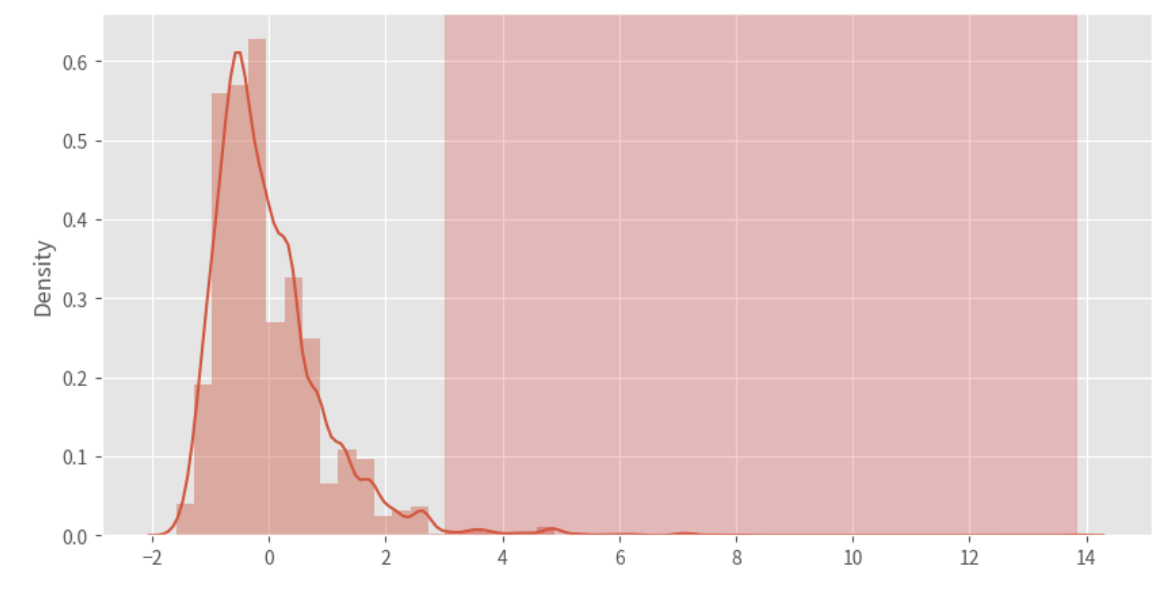

- 중심 분포 : 그래프의 중앙 부분은 z-score의 값이 -2에서 2사이에 집중, 비교적데이터 포인트가 평균에서 가까운 범위 내에 있음을 의미 
- 이상치 강조 : 이상치는 낮은 및도 
- 왼쪽 꼬리 : -3이하는 해당 범위에 이상치가 없거나 매우 적음을 의미 
- 오른쪽 꼬리 : 이상치가 존재 

## z-score 직접 계산 후 이상치 제거 

```python
Z_train = X_train.copy()

# Train 데이터의 평균, 표준편차 계산
mean_train = Z_train['income_total'].mean()
std_train = Z_train['income_total'].std()

# 임계값 설정
threshold = 3

# Train 데이터로 Z-점수 계산 및 이상치 제거
Z_train['z_score_income'] = (Z_train['income_total'] - mean_train) / std_train
train_no_outliers = Z_train[Z_train['z_score_income'].abs() <= threshold]

train_no_outliers = train_no_outliers.drop('z_score_income', axis=1)
train_no_outliers.shape
```

## Result 

```
(11050, 19)
```

# stats z-score 

```python
from scipy import stats

Z_scipy_train = X_train.copy()

# Train 데이터에 대해 Z-score 계산
Z_scipy_train['z_score_income'] = stats.zscore(Z_scipy_train['income_total'])

# 임계값 설정
threshold = 3

# 임계값을 기반으로 Train 데이터에서 이상치 제거
train_no_outliers = Z_scipy_train[Z_scipy_train['z_score_income'].abs() <= threshold]

# 임시 Z-score 컬럼 제거
train_no_outliers = train_no_outliers.drop('z_score_income', axis=1)
train_no_outliers.shape
```

## result 

```
(11050, 19)
```

## Z-Score 기법의 장점과 단점

### 장점 👍

- 간단하고 직관적
Z-Score는 평균과 표준편차를 이용한 간단한 계산으로 이루어져 있어, 구현하기 쉽고 결과 해석이 직관적입니다.

- 표준화된 점수
데이터 포인트가 데이터셋의 평균으로부터 얼마나 떨어져 있는지를 표준화된 형태로 표현하여, 서로 다른 데이터셋이나 변수 간 비교가 용이합니다.

- 정규 분포 데이터에 적합
데이터가 정규 분포를 따르는 경우, Z-Score는 이상치를 식별하는 데 매우 효과적입니다.

- 확장성
다양한 임계값 설정이 가능하며, 데이터의 특성에 맞게 조정할 수 있어 융통성이 뛰어납니다.

### 단점 👎

- 정규 분포 의존성
Z-Score 방법은 데이터가 정규 분포를 가정할 때 가장 잘 작동합니다. 데이터가 크게 비대칭적이거나 긴 꼬리를 가진 경우, 이상치 탐지에 오류가 발생할 수 있습니다.

- 극단값에 민감
극단적인 값이 포함된 경우, 이들 값이 평균과 표준편차에 큰 영향을 미칠 수 있으며, 이는 Z-Score 계산에 영향을 미칩니다.

- 모든 이상치를 식별하지 못할 수 있음
Z-Score는 간단한 통계적 접근 방식이기 때문에, 모든 유형의 이상치를 완벽히 식별하지 못할 수 있습니다. 특히, 데이터셋에 이상치가 많은 경우 효과적이지 않을 수 있습니다.

- 이진 결정의 어려움
어떤 데이터 포인트를 이상치로 간주할지에 대한 명확한 기준이 없기 때문에, 임계값 설정이 주관적일 수 있으며, 이에 따라 결과가 달라질 수 있습니다.

Z-Score를 이용한 이상치 제거 방법은 이러한 장단점을 고려하여 신중히 적용해야 하며, 경우에 따라 다른 이상치 탐지 방법과 병행하여 사용하는 것이 좋습니다. 데이터의 특성과 분석 목적에 따라 적절한 방법을 선택하는 것이 중요합니다.  



## IQR

### IQR을 이용한 이상치 탐지 실습

Quantile 함수를 활용하여 IQR 이상치 제거 : pandas 라이브러리의 quantile 함수를 사용하여 데이터 세트의 25번째 백분위수(Q1)와 75번째 백분위수(Q3)를 계산하고, 이를 통해 IQR을 구합니다.   
이상치는 Q1에서 1.5 * IQR을 뺀 값보다 작거나, Q3에 1.5 * IQR을 더한 값보다 큰 데이터 포인트로 정의됩니다. 이상치로 간주된 데이터 포인트들은 분석에서 제외하거나 추가 조사를 통해 처리될 수 있습니다.

Percentile 함수를 활용하여 IQR 이상치 제거: NumPy 라이브러리의 percentile 함수를 사용하여 동일한 백분위수를 계산합니다.  
이 함수는 전체 데이터 배열을 입력으로 받아, 지정된 백분위수에 해당하는 값을 반환합니다. 이후, quantile 함수와 유사하게 IQR을 구하고 이상치를 식별할 수 있습니다.

```python
plt.boxplot(X_train['income_total'], vert=False) 
plt.title('Boxplot for Feature income_total') 
plt.show() 

def out_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# 'income_total' 열의 이상치를 찾기 위한 조건
lower_bound, upper_bound = out_iqr(X_train['income_total'])

# 이상치를 각각의 조건으로 찾음
lower_outliers = X_train[X_train['income_total'] < lower_bound]
upper_outliers = X_train[X_train['income_total'] > upper_bound]

# 각각의 이상치 개수 계산
num_lower_outliers = len(lower_outliers)
num_upper_outliers = len(upper_outliers)

print("Number of lower outliers in 'income_total' column:", num_lower_outliers)
print("Number of upper outliers in 'income_total' column:", num_upper_outliers)
```

## Result

```
Number of lower outliers in 'income_total' column: 0
Number of upper outliers in 'income_total' column: 467
```

## quantile 함수를 활용하여 IQR 이상치 제거 

```python
lower_bound, upper_bound = out_iqr(X_train['income_total'])
train_no_outliers_iqr = X_train[(X_train['income_total'] >= lower_bound) & (X_train['income_total'] <= upper_bound)]

print("Shape of train data after removing outliers using IQR:", train_no_outliers_iqr.shape)
```

```
Shape of train data after removing outliers using IQR: (10734, 19)
```

## Percentile 함수를 활용하여 iqr 이상치 제거 

```python
Q1 = np.percentile(X_train['income_total'], 25)
Q3 = np.percentile(X_train['income_total'], 75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR

train_no_outliers_iqr_np = X_train[(X_train['income_total'] > lower_bound) & (X_train['income_total'] < upper_bound)]

print("Shape of train data after removing outliers using NumPy's percentile:", train_no_outliers_iqr.shape)
```

---

## Result 

```
Shape of train data after removing outliers using NumPy's percentile: (10734, 19)

```

## IQR을 활용한 이상치 탐지의 장점과 단점

### 장점 👍

- **강한 내성 (Robustness)**
  IQR은 데이터의 중앙 50% 영역에 초점을 맞추므로, 아주 극단적인 값(이상치)이 새롭게 추가되더라도 그 영향을 적게 받습니다. 데이터 분포가 비대칭적일 때 매우 유리합니다.

- **직관적인 이해**
  데이터를 4등분 하는 사분위수 개념에 기반하기 때문에, 계산 방식이나 "정상 범주"의 의미를 누구나 쉽게 그림(Boxplot 등)으로 이해할 수 있습니다.

- **비모수적 접근 (Non-parametric)**
  Z-score처럼 데이터가 꼭 정규 분포(종 모양)를 따라야 한다는 가정이 필요 없습니다. 분포 형태가 불규칙한 실무 데이터에서도 널리 쓰일 수 있습니다.

---

### 단점 👎

- **중요 정보 손실 위험**
  수식에 의해 기계적으로 제거된 이상치 안에, 사실은 문제 해결(예: 사기 거래 탐지, 암 진단 등)에 꼭 필요한 핵심 신호가 숨어 있었을 확률도 배제할 수 없습니다.

- **임계값의 임의성**
  일반적으로 $\text{Q1} - 1.5 \times \text{IQR}$ , $\text{Q3} + 1.5 \times \text{IQR}$ 을 기준으로 삼지만, 이 '$1.5$'라는 숫자는 절대적인 진리가 아닌 어느 정도 임의적인 설정입니다. 데이터 특성에 따라 3.0을 적용해야 하는 등 조율이 필요합니다.

> **💡 요약:** IQR은 극단값이 많은 데이터일수록 안전하고 훌륭한 이상치 탐지 기법입니다. 단, 무조건 제거하기보다는 제거 대상이 '진짜 버려도 되는 에러값'인지 꼭 한 번 확인하는 습관이 중요합니다.

데이터 변환: 이상치의 영향을 줄이기 위해 데이터를 변환할 수 있습니다. 데이터를 로그로 변환하거나, 제곱근을 취하거나, 역수를 취하는 등의 방법을 사용하여 데이터의 분포를 조절할 수 있습니다. 이렇게 하면 이상치의 영향을 줄일 수 있습니다.

이상치 점수화: 이상치를 제거하지 않고 데이터에서 이상치를 식별하고 점수화할 수 있습니다. 이 점수를 활용하여 모델링에 활용하거나, 이상치의 정도를 파악할 수 있습니다.

이상치 치환: 이상치를 다른 값으로 대체할 수 있습니다. 이상치를 해당 특성의 중앙값이나 평균값 등으로 대체하거나, 가장 가까운 정상치로 대체하는 방법을 사용할 수 있습니다.

모델 기반 접근: 일부 머신 러닝 모델은 이상치에 강건하며, 이상치를 자동으로 처리할 수 있습니다. 예를 들어, 랜덤 포레스트와 같은 트리 기반 모델은 이상치에 민감하지 않을 수 있습니다.

이상치를 고려한 모델링: 때로는 이상치가 중요한 정보를 제공하는 경우도 있습니다. 이런 경우, 이상치를 제거하지 않고 모델링을 수행하고, 결과에 미치는 영향을 조사하는 것이 유용할 수 있습니다.

# DBSCAN ( Density-based spatial clustering of applications with noise )